# 01 - Keşifsel Veri Analizi (EDA) — CICIDS2017

Bu notebook, 8 günlük CICIDS2017 CSV dosyasının birleşimini (`data/processed/full.parquet`, `src/load_data.py` ile üretildi) inceler: sınıf dağılımı, veri kalitesi sorunları (Inf/NaN, sabit/kopya sütunlar, kopya satırlar) ve saldırı vs normal trafiğin ayırt edici özellikleri.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from clean import map_to_category, CONSTANT_COLUMNS, DUPLICATE_COLUMNS

sns.set_style('whitegrid')

df = pd.read_parquet('../data/processed/full.parquet')
print('Boyut:', df.shape)
df.head(3)

Boyut: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


## 1. Sütun adları ve sınıf (Label) dağılımı

Sütun adları `src/load_data.py` içinde zaten `str.strip()` ile temizlendi (kaynak CSV'lerde bazı sütun adlarının başında/sonunda boşluk olduğu bilinen bir sorundur). Ham `Label` sütunundaki 15 farklı değeri (14 saldırı alt türü + BENIGN) inceliyoruz.

Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11
Name: count, dtype: int64


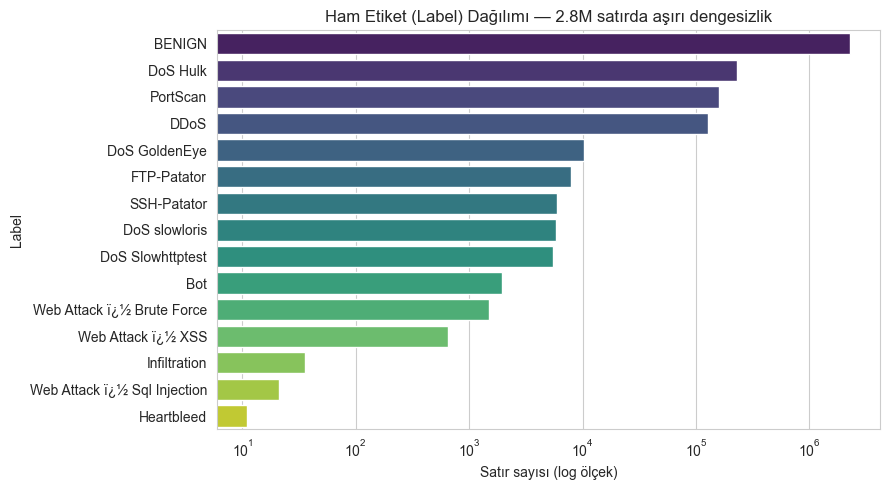

In [2]:
label_counts = df['Label'].value_counts()
print(label_counts)

plt.figure(figsize=(9, 5))
sns.barplot(x=label_counts.values, y=label_counts.index, hue=label_counts.index, palette='viridis', legend=False)
plt.xscale('log')
plt.xlabel('Satır sayısı (log ölçek)')
plt.title('Ham Etiket (Label) Dağılımı — 2.8M satırda aşırı dengesizlik')
plt.tight_layout()
plt.savefig('../results/figures/eda_label_distribution.png', dpi=150)
plt.show()

**Not:** `Web Attack` etiketlerinde kaynak dosyadan gelen bir encoding bozukluğu var (`Web Attack ï¿½ Brute Force` gibi — orijinal metindeki tire karakteri bozulmuş). Bu yüzden `src/clean.py` içindeki `map_to_category` fonksiyonu tam string eşleşmesi yerine `'Web Attack' in label` alt string kontrolü kullanıyor.

## 2. Veri kalitesi sorunları: Infinity, NaN ve negatif hız değerleri

`Flow Bytes/s` ve `Flow Packets/s` sütunlarında bölme-sıfıra-bölünme kaynaklı `Infinity` değerleri olduğu CICIDS2017 literatüründe bilinen bir sorundur. Ayrıca aynı iki sütunda **negatif** değerler de bulundu — bir hız fiziksel olarak negatif olamayacağından bu da CICFlowMeter aracının nadir bir hatası olarak değerlendirilip temizlenir.

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = {col: int(np.isinf(df[col]).sum()) for col in numeric_cols if np.isinf(df[col]).sum() > 0}
nan_counts = df.isna().sum()
nan_counts = nan_counts[nan_counts > 0]
negative_rate_counts = {
    col: int((df[col] < 0).sum())
    for col in ['Flow Bytes/s', 'Flow Packets/s']
    if (df[col] < 0).sum() > 0
}

print('Inf iceren sutunlar ve sayilari:', inf_counts)
print()
print('NaN iceren sutunlar ve sayilari:')
print(nan_counts)
print()
print('Negatif deger iceren hiz sutunlari ve sayilari:', negative_rate_counts)

total_bad = len(df[
    np.isinf(df['Flow Bytes/s']) | np.isinf(df['Flow Packets/s']) | df['Flow Bytes/s'].isna()
    | (df['Flow Bytes/s'] < 0) | (df['Flow Packets/s'] < 0)
])
pct = 100 * total_bad / len(df)
print()
print('En az bir Inf/NaN/negatif deger iceren toplam satir:', total_bad, '- oran: %{:.3f}'.format(pct))


Inf iceren sutunlar ve sayilari: {'Flow Bytes/s': 1509, 'Flow Packets/s': 2867}

NaN iceren sutunlar ve sayilari:
Flow Bytes/s    1358
dtype: int64

Negatif deger iceren hiz sutunlari ve sayilari: {'Flow Bytes/s': 85, 'Flow Packets/s': 115}

En az bir Inf/NaN/negatif deger iceren toplam satir: 2982 - oran: %0.105


## 3. Sabit ve kopya sütunlar

Varyansı sıfır olan (her satırda aynı değeri taşıyan) sütunlar modele hiçbir bilgi katmaz; `Fwd Header Length.1` ise `Fwd Header Length` ile birebir aynı olduğu doğrulanmış bir kopya sütundur.

In [4]:
nunique = df.nunique()
constant_cols = nunique[nunique <= 1].index.tolist()
print('Tespit edilen sabit sütunlar:', constant_cols)
print('clean.py içinde silinecek olarak tanımlı:', CONSTANT_COLUMNS)
assert set(constant_cols) == set(CONSTANT_COLUMNS), 'Sabit sutun listesi guncel veriyle uyusmuyor!'

print('\nFwd Header Length ile Fwd Header Length.1 birebir ayni mi:',
      (df['Fwd Header Length'] == df['Fwd Header Length.1']).all())

Tespit edilen sabit sütunlar: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
clean.py içinde silinecek olarak tanımlı: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']

Fwd Header Length ile Fwd Header Length.1 birebir ayni mi: True


## 4. Tam kopya satırlar

Aynı flow istatistiklerine sahip birden fazla satır (farklı bağlantılar aynı akış özetini üretebiliyor) veri setinde ciddi oranda mevcut.

In [5]:
dup_count = df.duplicated().sum()
print(f'Tam kopya satır sayısı: {dup_count:,} (toplamın %{100*dup_count/len(df):.2f}\'si)')

Tam kopya satır sayısı: 256,479 (toplamın %9.06'si)


## 5. Saldırı vs Normal: anahtar özelliklerin dağılımı

Temizlenmiş (Inf/NaN silinmiş) veriden 200 bin satırlık bir örneklemle, saldırı (Category != BENIGN) ve normal trafiğin birkaç anahtar özellikte gözle görülür şekilde ayrışıp ayrışmadığına bakıyoruz. `Category` sütunu `map_to_category` ile 7 ana sınıfa indirgenmiş etikettir.

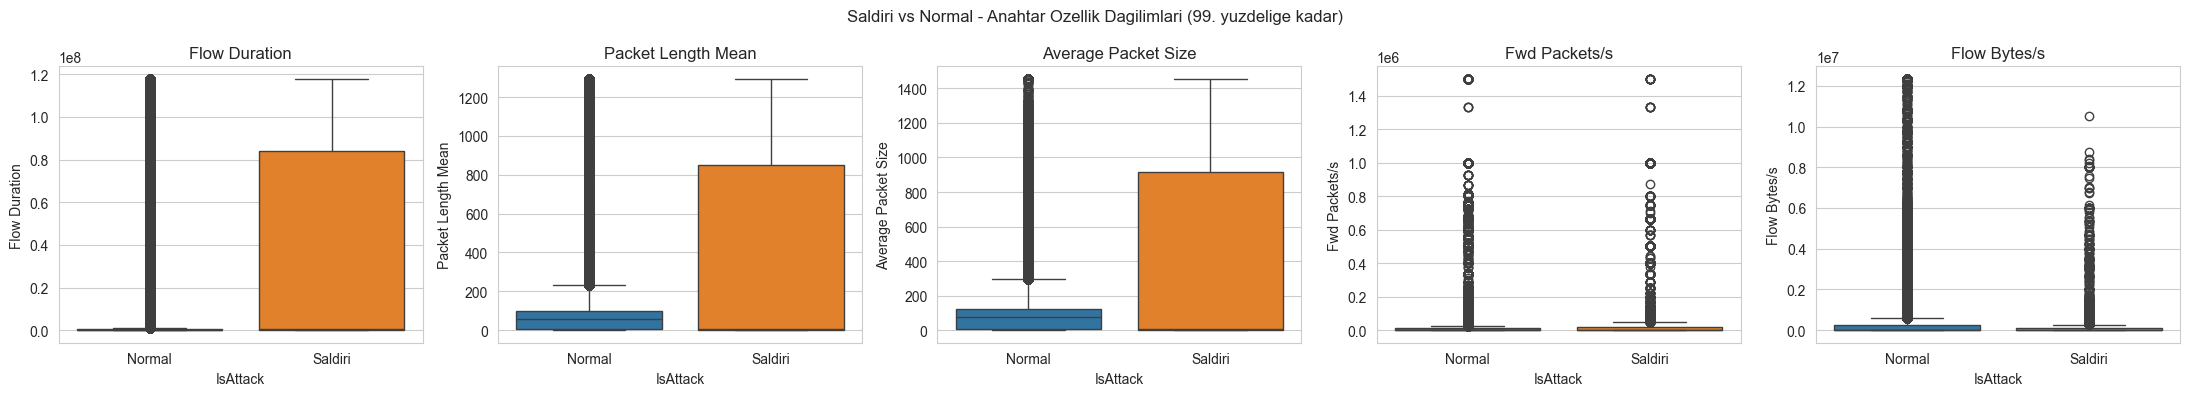

In [6]:
df_clean_view = df.replace([np.inf, -np.inf], np.nan).dropna(subset=numeric_cols)
df_clean_view = df_clean_view.drop(columns=[c for c in CONSTANT_COLUMNS + DUPLICATE_COLUMNS if c in df_clean_view.columns])
df_clean_view = df_clean_view[(df_clean_view['Flow Bytes/s'] >= 0) & (df_clean_view['Flow Packets/s'] >= 0)]
df_clean_view['Category'] = df_clean_view['Label'].apply(map_to_category)
df_clean_view['IsAttack'] = (df_clean_view['Category'] != 'BENIGN').map({True: 'Saldiri', False: 'Normal'})

sample = df_clean_view.sample(n=200_000, random_state=42)

key_features = ['Flow Duration', 'Packet Length Mean', 'Average Packet Size', 'Fwd Packets/s', 'Flow Bytes/s']
fig, axes = plt.subplots(1, len(key_features), figsize=(22, 4))
for ax, feat in zip(axes, key_features):
    q99 = sample[feat].quantile(0.99)
    sns.boxplot(data=sample[sample[feat] <= q99], x='IsAttack', y=feat, hue='IsAttack', ax=ax, legend=False)
    ax.set_title(feat)
plt.suptitle('Saldiri vs Normal - Anahtar Ozellik Dagilimlari (99. yuzdelige kadar)')
plt.tight_layout()
plt.savefig('../results/figures/eda_attack_vs_normal.png', dpi=150)
plt.show()

## Bulgular

- **Aşırı sınıf dengesizliği:** BENIGN 2.27M satırla ham veri setinin %80'inden fazlasını oluşturuyor; en nadir sınıf olan `Infiltration` sadece 36 satır. Bu, hem ikili hem çok sınıflı modellemede `class_weight`/SMOTE gibi dengesizlik önlemlerini zorunlu kılıyor ve `Infiltration` sınıfında yüksek skor beklememek gerektiğini gösteriyor.
- **Inf/NaN kaynağı belirlendi:** `Flow Bytes/s` ve `Flow Packets/s` sütunlarındaki Inf değerleri, akış süresinin (Flow Duration) sıfır olduğu çok kısa/anlık bağlantılarda payda sıfıra bölündüğü için oluşuyor. Toplam etkilenen satır oranı binde 1 civarında olduğundan bu satırları silmek güvenli.
- **Negatif hız değerleri:** Aynı `Flow Bytes/s` / `Flow Packets/s` sütunlarında 113 satırda (tamamı BENIGN) fiziksel olarak imkansız negatif değerler bulundu — CICFlowMeter'in bilinen nadir bir üretim hatası. Inf/NaN temizliğiyle aynı mantıkla (satır sayısı ihmal edilebilir düzeyde) bu satırlar da `src/clean.py` içinde siliniyor.
- **8 sabit sütun + 1 kopya sütun tespit edildi** (`Fwd Header Length.1`); bunlar `src/clean.py` içinde otomatik olarak çıkarılıyor.
- **%9'a yakın tam kopya satır** bulundu — muhtemelen aynı flow istatistiklerini üreten farklı bağlantılar (özellikle kısa/basit BENIGN trafik veya DoS gibi tekrarlayan saldırı desenlerinde beklenir). Modelin bu kopyaları ezberlememesi için siliniyor.
- **Saldırı vs normal ayrışması görsel olarak belirgin — ama sezgisel beklenti her zaman doğrulanmıyor:** İlk denemede "SYN Flag Count saldırıda yüksektir" varsayımıyla bu özelliği grafiğe koymuştuk; sayısal kontrolde bunun **yanlış** olduğu ortaya çıktı — BENIGN trafikte SYN oranı (%5.5) saldırı ortalamasından (%1.2) daha yüksek. Kategori bazında incelendiğinde SYN Flag Count aslında sadece `Infiltration` (%55.6) ve `BruteForce` (%28.6) alt kümelerinde yüksek; `DoS/DDoS`, `PortScan` ve `WebAttack` kategorilerinde neredeyse hiç SYN bayrağı yok. Yedi farklı saldırı türünü tek bir "Saldırı" etiketinde toplamak bu tür alt-kategoriye özgü sinyalleri maskeleyebiliyor — bu, ham sezgiyle değil sayısal doğrulamayla ilerlemenin önemine dair somut bir örnek ve rapora taşınacak bir bulgu.
- **Gerçekten ayırt edici özellikler:** `Average Packet Size` (normalde medyan 74.3, saldırıda 7.5), `Flow Bytes/s` (5150 vs 144) ve `Fwd Packets/s` (63.8 vs 10.0) saldırı vs normal arasında büyük ve tutarlı farklar gösteriyor — saldırı trafiğinin (özellikle DoS/PortScan ağırlıklı) çok küçük paketlerle, düşük bayt/s hızında ama yüksek paket sıklığında aktığına işaret ediyor. Bu özellikler ikili sınıflandırma modelinde güçlü sinyal kaynağı olacaktır.
- **Web Attack etiketlerinde encoding bozukluğu** tespit edildi ve alt string eşlemesiyle (`'Web Attack' in label`) güvenli şekilde ele alındı; bu, ham veriyle çalışırken körü körüne tam string eşleşmesine güvenmemek gerektiğinin bir hatırlatıcısı.